# Notebook Instructions

1. If you are new to Jupyter notebooks, please go through this introductory manual <a href='https://quantra.quantinsti.com/quantra-notebook' target="_blank">here</a>.
1. Any changes made in this notebook would be lost after you close the browser window. **You can download the notebook to save your work on your PC.**
1. Before running this notebook on your local PC:<br>
i.  You need to set up a Python environment and the relevant packages on your local PC. To do so, go through the section on "**Run Codes Locally on Your Machine**" in the course.<br>
ii. You need to **download the zip file available in the last unit** of this course. The zip file contains the data files and/or python modules that might be required to run this notebook.

# Detect the Inverse Head and Shoulders Pattern

In the previous units, you learnt how to identify and trade inverse head and shoulders pattern. In this unit, you will learn to programmatically identify the inverse head and shoulders pattern. In addition to this, you will also learn how to define risk metrics for the inverse head and shoulders pattern.

This notebook is structured as follows:
1. [Import Libraries](#libraries)
2. [Read the Data](#data)
3. [Local Minima and Maxima](#lmm)
4. [Inverse Head and Shoulders Scanner](#head-and-shoulder)
5. [Visualise the Inverse Head and Shoulders Patterns](#visualise)
6. [Trade the Inverse Head and Shoulders Pattern](#trade)
7. [Risk Management](#riskmanagement)
8. [Conclusion and Next Steps](#conclusion)


<a id='libraries'></a>
## Import Libraries

In [1]:
# For data manipulation
import pandas as pd
import numpy as np
import datetime as datetime
from datetime import datetime

# For visualisation
import matplotlib.pyplot as plt
import mplfinance as mpf
plt.style.use('seaborn-v0_8-darkgrid')

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Import utility function
import sys
sys.path.append('..')
from data_modules.price_action_util_quantra import get_min_max

<a id='data'></a>
## Read the Data

Import the file `apple_daily_1980_2022.csv` using the `read_csv` method of `pandas`. This file has the OHLCV values for Apple stock in the daily frequency. This CSV file is available in the zip file of the unit 'Python Codes and Data' in the 'Course Summary' section.

In [2]:
# Import the stock price data
data = pd.read_csv('../data_modules/apple_daily_1980_2022.csv', index_col=0)

# Change the index type of data to datetime
data.index = pd.to_datetime(data.index)

# Print first 5 rows of the data
data.head()

,Open,High,Low,Close,Volume
Date,,,,,
1980-12-12,0.100040,0.100474,0.100040,0.100040,469033600
1980-12-15,0.095255,0.095255,0.094820,0.094820,175884800
1980-12-16,0.088296,0.088296,0.087861,0.087861,105728000
1980-12-17,0.090035,0.090470,0.090035,0.090035,86441600
1980-12-18,0.092646,0.093081,0.092646,0.092646,73449600


<a id='lmm'></a>
## Local Minima and Maxima
Using `get_min_max()` function, calculate local minima and local maxima of `data` and store in the dataframes `minima_prices` and `maxima_prices` respectively.

In [3]:
# Use get_min_max() function to generate minima_prices and maxima_prices
minima_prices, maxima_prices = get_min_max(data, 5)

# Store values of both local minima and local maxima points in a sequential order in 'min_max' dataframe
min_max = pd.concat([minima_prices, maxima_prices]).sort_index()

min_max.tail()

Date
2022-06-30    133.584445
2022-08-17    176.149994
2022-09-12    164.259995
2022-09-16    148.369995
2022-09-21    158.740005
dtype: float64

<a id='head-and-shoulder'></a>
## Inverse Head and Shoulders Scanner

Typically, the image shown below represents what an inverse head and shoulders pattern typically looks like.



<img src="https://d2a032ejo53cab.cloudfront.net/Glossary/8mVrjk4J/ihs.JPG" width="500">

To classify a sequence of 5 local minima and maxima points (such as A, B, C, D and E in above figure) as an inverse head and shoulders pattern, we need to check for some of the following conditions:

1. Points **A, C and E** must come under the set of local **minima points**. This is because they represent the troughs of the  inverse head and shoulders.
<br>

2. Points **B and D** should lie in the set of local **maxima points**, as they form the neckline of the pattern.
<br>

3. The five sequential points must exhibit relations as follows:
 *  Points **B and D** must be greater than  **A and E** to make sure the shoulders are above the neckline.
 * Points **A and E** must be greater than  **C** to make sure the head is below the neckline.
<br>


4. The two points **A and E** (that form the two shoulder troughs) must not lie at a distance greater than 1.5% away from their mean. For example, if the average of **A and E** is 100, then the difference between **A and E** must not be greater than 1.5.  And the same goes for points **B and D** (that form the neckline).


You can refer to the book <a href='https://www.google.co.in/books/edition/Advanced_Trading_Rules/27Vo8RPc12wC?hl=en&gbpv=1&dq=patterns%5B%27IHS%27%5D&pg=PA53&printsec=frontcover
' target="_blank">Advanced Trading Rules</a> by Emmanual Acar and Stephen Satchell to get some deeper insights behind the conditions used to detect an inverse head and shoulders pattern.


### Create the Inverse Head and Shoulders Scanner

Considering the above conditions, we will now create a scanner. It should be observed that the following function is similar to the head and shoulders scanner function but with the conditions listed above.

In [4]:
# Inverse Head and shoulders scanner function
def ihs_scanner(min_max, minima_prices, maxima_prices, frequency='daily'):

    # To store pattern instances
    patterns = []

    # Loop to iterate along the price data
    for i in range(5, len(min_max)):

        # Store 5 local minima and local maxima points at a time in the variable 'window'
        window = min_max.iloc[i-5:i]

        # Determine window length based on the frequency of data
        if frequency == 'daily':
            window_size = (window.index[-1] - window.index[0]).days
        else:
            window_size = (window.index[-1] - window.index[0]).seconds/60/60

        # Ensure that pattern is formed within 100 bars
        if window_size > 100:
            continue

        # Store the 5 unique points to check for conditions
        a, b, c, d, e = [window[i] for i in range(0, len(window))]

        # cond_1: To check a,c,e are in minima_prices
        cond_1 = all(x in minima_prices.values for x in [a, c, e])

        # cond_2: To check b,d are in maxima_prices
        cond_2 = all(x in maxima_prices.values for x in [b, d])

        # cond_3: To check if the shoulders are above the neckline and the head is below the neckline
        cond_3 = (a > c) and (b > a) and (b > c) and (d > e) and (d > c)

        # cond_4: To check if A and E (and also B and D) are at a distance less than 1.5% away from their mean
        cond_4 = (abs(a-e) <= np.mean([a, e]) *
                  0.015) and (abs(b-d) <= np.mean([b, d])*0.015)

        # Checking if all conditions are true
        if cond_1 and cond_2 and cond_3 and cond_4:

            # Append the pattern to list if all conditions are met
            patterns.append(
                ([window.index[i] for i in range(0, len(window))]))

    return patterns

In [5]:
# Detect inverse head and shoulders patterns and store the results
ihs_patterns = ihs_scanner(min_max, minima_prices, maxima_prices)

# Check the total instances of the pattern
len(ihs_patterns)

5

This shows us that we have about 5 instances of the inverse head and shoulders pattern in the Apple's stock data since the year 1980. As of now, under `ihs_patterns` we have the indices of the set of 5 sequential points that form an inverse head and shoulders pattern.

### Store the Pattern Details

To be able to take trades based on the inverse head and shoulders pattern, we will also require some additional information such as the dates and prices corresponding to the formation of the head, shoulders and neckline structures. Let us fetch all of this information and store it in a dataframe called `ihs_patterns_data`.

In [6]:
# Initialise the dataframe and specify column names
ihs_patterns_data = pd.DataFrame(ihs_patterns)
ihs_patterns_data.columns = ['sh1_date', 'neck1_date',
                             'head_date', 'neck2_date', 'sh2_date']

# Populate the dataframe with relevant values
ihs_patterns_data['sh1_price'] = data.loc[ihs_patterns_data.sh1_date, 'Low'].values
ihs_patterns_data['neck1_price'] = data.loc[ihs_patterns_data.neck1_date, 'High'].values
ihs_patterns_data['head_price'] = data.loc[ihs_patterns_data.head_date, 'Low'].values
ihs_patterns_data['neck2_price'] = data.loc[ihs_patterns_data.neck2_date, 'High'].values
ihs_patterns_data['sh2_price'] = data.loc[ihs_patterns_data.sh2_date, 'Low'].values

# Display the pattern details for each instance
ihs_patterns_data.tail()

,sh1_date,neck1_date,head_date,neck2_date,sh2_date,sh1_price,neck1_price,head_price,neck2_price,sh2_price
0,2003-02-10,2003-02-18,2003-02-24,2003-03-03,2003-03-12,0.214372,0.233279,0.210409,0.231144,0.214372
1,2014-12-16,2014-12-29,2015-01-06,2015-01-09,2015-01-16,23.952008,25.870246,23.584591,25.527619,23.713076
2,2015-04-17,2015-04-28,2015-05-06,2015-05-22,2015-06-09,28.165181,30.446268,27.916258,30.216676,28.546440
3,2017-11-15,2017-11-24,2017-12-06,2017-12-18,2017-12-29,40.094529,41.789937,39.637336,42.194735,40.294549
4,2021-02-23,2021-03-02,2021-03-08,2021-03-16,2021-03-30,117.354828,127.594507,115.193885,126.107612,117.820724


<a id='visualise'></a>
## Visualise the Inverse Head and Shoulders Pattern

In the upcoming cells, we will perform some simple steps in order to visualise the inverse head and shoulders pattern using the `mplfinance` library. We have multiple instance of the inverse head and shoulders pattern, but, for now let us plot one pattern at a time.

### Specify the Pattern to Plot

In the below cell, we have set the `pattern_index` as `-1` since we want to plot the most recent pattern. However, feel free to change this value if you wish to plot a different inverse head and shoulders instance.

In [7]:
# Specify the pattern index
pattern_index = -1

# Initialise the pattern data
ihs_patterns_to_plot = ihs_patterns_data.iloc[pattern_index]
points = int(len(ihs_patterns_to_plot)/2)

# Capture the pattern details for the most recent pattern
ihs = pd.DataFrame()
ihs['dates'] = ihs_patterns_to_plot.iloc[:points]
ihs['price'] = ihs_patterns_to_plot.iloc[points:].values
ihs

,dates,price
sh1_date,2021-02-23 00:00:00,117.354828
neck1_date,2021-03-02 00:00:00,127.594507
head_date,2021-03-08 00:00:00,115.193885
neck2_date,2021-03-16 00:00:00,126.107612
sh2_date,2021-03-30 00:00:00,117.820724


In [8]:
# Pattern Details
ihs_patterns_to_plot

sh1_date       2021-02-23 00:00:00
neck1_date     2021-03-02 00:00:00
head_date      2021-03-08 00:00:00
neck2_date     2021-03-16 00:00:00
sh2_date       2021-03-30 00:00:00
sh1_price               117.354828
neck1_price             127.594507
head_price              115.193885
neck2_price             126.107612
sh2_price               117.820724
Name: 4, dtype: object

### Get the OHLCV Data Corresponding to the Pattern

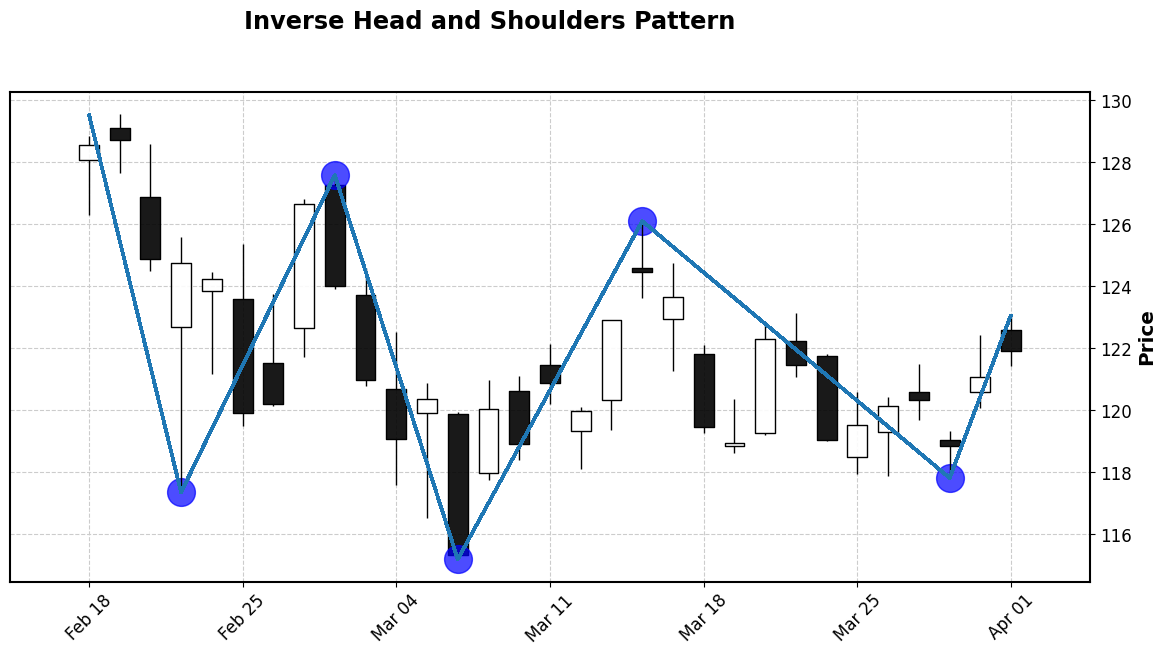

In [9]:
# Initialise the start and end dates for OHLCV data
start_index = data.index.get_loc(ihs.dates[0]) - 3
last_index = data.index.get_loc(ihs.dates[-1]) + 3

# Fetch the OHLCV data for the period
data_to_plot = data.iloc[start_index:last_index]

# Add pattern details to data_to_plot
data_to_plot['pattern'] = np.nan
data_to_plot.loc[ihs.dates, 'pattern'] = ihs.price.values

# Define scatter plot to mark the 5 sequential points forming the pattern
ihs_plot = mpf.make_addplot(data_to_plot.pattern, type='scatter', marker='o', markersize=400,
                            panel=0, color="blue", alpha=0.7)

# Define subplot of a line that will connect the 5 sequential points
pattern_line = [(data_to_plot.index[0], data.iloc[start_index:data.index.get_loc(ihs.dates[0])].max()['High'])] + list(ihs.itertuples(
    index=False, name=None)) + [(data_to_plot.index[-1], data.iloc[data.index.get_loc(ihs.dates[-1]):last_index].max()['High'])]

# Plot the candlestick chart along with pattern related subplots
mpf.plot(data_to_plot, type='candle', style='classic', addplot=ihs_plot,
         title='Inverse Head and Shoulders Pattern', figsize=(15, 7), alines=pattern_line)

<a id='trade'></a>
## Trade the Inverse Head and Shoulders Pattern

Find the long entry date of the inverse head and shoulders pattern and store it in the column `confirmation_date` of `ihs_patterns_data`

In [10]:
# Function to calculate the long entry date of the inverse head and shoulders pattern
def get_confirmation_date(ihs_patterns, data=data):

    # Store the data after second shoulder in 'data_after_sh2'
    data_after_sh2 = data.loc[ihs_patterns.sh2_date:]['Close']

    try:
        # Return the long entry date if price went above the second shoulder price
        return data_after_sh2[data_after_sh2 > ihs_patterns.neck2_price].index[0]

    except:
        # Return NaN if price never went above the second shoulder price
        return np.nan


# Create the column 'confirmation_date' to store the long entry dates calculated using the function get_confirmation_date()
ihs_patterns_data['confirmation_date'] = ihs_patterns_data.apply(
    get_confirmation_date, axis=1)

For an efficient trading scenario:

1) The `time_for_confirmation` must be more than 5 bars away to avoid look-ahead bias<br>
This ensures that trades are not taken before the pattern is completely formed.

2) The `time_for_confirmation` must occur within 30 bars<br>
This ensures that the pattern is not occurring over an excessively long duration, as generally such patterns would not qualify as good inverse head and shoulders patterns. 

The result is a subset of the data that meets both conditions and represents valid inverse head and shoulders patterns where we can take trades.

In [11]:
# Drop NaN values from 'ihs_patterns_data'
ihs_patterns_data.dropna(inplace=True)

# Store the number of days taken to generate long entry date 
ihs_patterns_data['time_for_confirmation'] = (
    ihs_patterns_data.confirmation_date - ihs_patterns_data.sh2_date).dt.days

# Selecting the patterns that generated long entry within 30 days of forming the right shoulder
ihs_patterns_data = ihs_patterns_data[(ihs_patterns_data['time_for_confirmation'] > 5) & (ihs_patterns_data['time_for_confirmation'] < 30)]

# Create'signal' column with values as '1' since we are buying once the pattern is confirmed
ihs_patterns_data['signal'] = 1

ihs_patterns_data.tail()

,sh1_date,neck1_date,head_date,neck2_date,sh2_date,sh1_price,neck1_price,head_price,neck2_price,sh2_price,confirmation_date,time_for_confirmation,signal
1,2014-12-16,2014-12-29,2015-01-06,2015-01-09,2015-01-16,23.952008,25.870246,23.584591,25.527619,23.713076,2015-01-28,12,1
3,2017-11-15,2017-11-24,2017-12-06,2017-12-18,2017-12-29,40.094529,41.789937,39.637336,42.194735,40.294549,2018-01-17,19,1
4,2021-02-23,2021-03-02,2021-03-08,2021-03-16,2021-03-30,117.354828,127.594507,115.193885,126.107612,117.820724,2021-04-07,8,1


### Plot the Pattern Along With the Long Entry Date

In [12]:
# Pattern details
ihs_patterns_to_plot

sh1_date       2021-02-23 00:00:00
neck1_date     2021-03-02 00:00:00
head_date      2021-03-08 00:00:00
neck2_date     2021-03-16 00:00:00
sh2_date       2021-03-30 00:00:00
sh1_price               117.354828
neck1_price             127.594507
head_price              115.193885
neck2_price             126.107612
sh2_price               117.820724
Name: 4, dtype: object

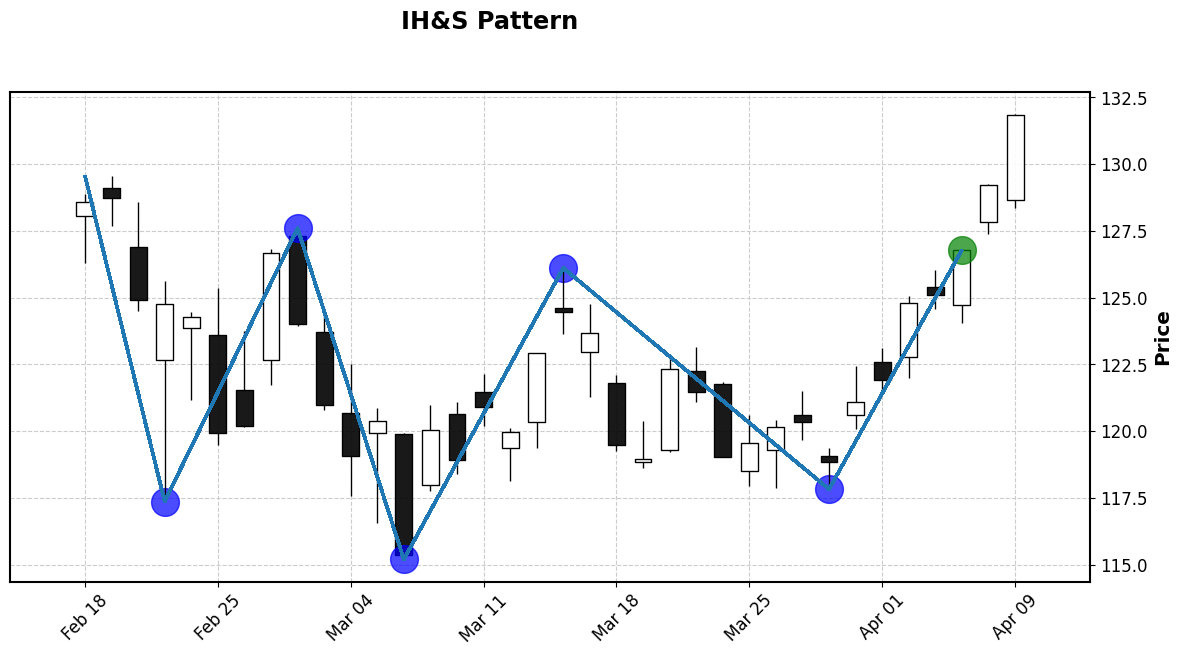

In [13]:
# Select the pattern data
ihs_patterns_to_plot = ihs_patterns_data.iloc[pattern_index]

# Capture the pattern details for the most recent pattern
ihs = pd.DataFrame()
ihs['dates'] = ihs_patterns_to_plot.iloc[:points]
ihs['price'] = ihs_patterns_to_plot.iloc[points:2*points].values

# Define the start and end date of the pattern to plot
start_index = data.index.get_loc(ihs.dates[0]) - 3
last_index = data.index.get_loc(ihs_patterns_to_plot.confirmation_date) + 3

# Select the data of pattern to plot
data_to_plot = data.iloc[start_index:last_index]
data_to_plot['pattern'] = np.nan
data_to_plot.loc[ihs.dates, 'pattern'] = ihs.price.values

# Define 'pattern_line' to draw the pattern
pattern_line = [(data_to_plot.index[0], data.iloc[start_index:data.index.get_loc(ihs.dates[0])].max()['High'])]+list(ihs.itertuples(index=False, name=None)) \
    + [(ihs_patterns_to_plot.confirmation_date,
        data.loc[ihs_patterns_to_plot.confirmation_date].Close)]

# Define list of markets and store in 'ihs_plot'
ihs_plot = [mpf.make_addplot(data_to_plot.pattern, type='scatter', marker='o', markersize=400,
                             panel=0, color="blue", alpha=0.7)]
data_to_plot['trade'] = np.nan
data_to_plot.loc[ihs_patterns_to_plot.confirmation_date,
                 'trade'] = data_to_plot.loc[ihs_patterns_to_plot.confirmation_date, 'Close']
ihs_plot += [mpf.make_addplot(data_to_plot.trade, type='scatter', marker='o', markersize=400,
                              panel=0, color="green", alpha=0.7)]

# Plot the candlestick plot of line plot and markets representing the selected pattern
mpf.plot(data_to_plot, type='candle', style='classic', addplot=ihs_plot,
         title='IH&S Pattern', figsize=(15, 7), alines=pattern_line)

<a id='riskmanagement'></a>
## Risk Management

Define a stop-loss 1% below the right shoulder and profit target at a distance of 'head_length' from the long entry price

In [14]:
# Stop-loss 1% below right shoulder
ihs_patterns_data['stoploss'] = ihs_patterns_data['sh2_price']*0.99

# Calculate the head length and store it in the column 'head_length'
ihs_patterns_data['head_length'] = ihs_patterns_data['neck2_price'] - \
    ihs_patterns_data['head_price']

# Calculate profit target and store it in the column 'target'
ihs_patterns_data['target'] = ihs_patterns_data['neck2_price'] + \
    1 * ihs_patterns_data['head_length']

ihs_patterns_data.tail()

,sh1_date,neck1_date,head_date,neck2_date,sh2_date,sh1_price,neck1_price,head_price,neck2_price,sh2_price,confirmation_date,time_for_confirmation,signal,stoploss,head_length,target
1,2014-12-16,2014-12-29,2015-01-06,2015-01-09,2015-01-16,23.952008,25.870246,23.584591,25.527619,23.713076,2015-01-28,12,1,23.475945,1.943028,27.470647
3,2017-11-15,2017-11-24,2017-12-06,2017-12-18,2017-12-29,40.094529,41.789937,39.637336,42.194735,40.294549,2018-01-17,19,1,39.891603,2.557399,44.752135
4,2021-02-23,2021-03-02,2021-03-08,2021-03-16,2021-03-30,117.354828,127.594507,115.193885,126.107612,117.820724,2021-04-07,8,1,116.642516,10.913727,137.021340


### Plot the Pattern Along With Stop-Loss and Take-Profit Levels

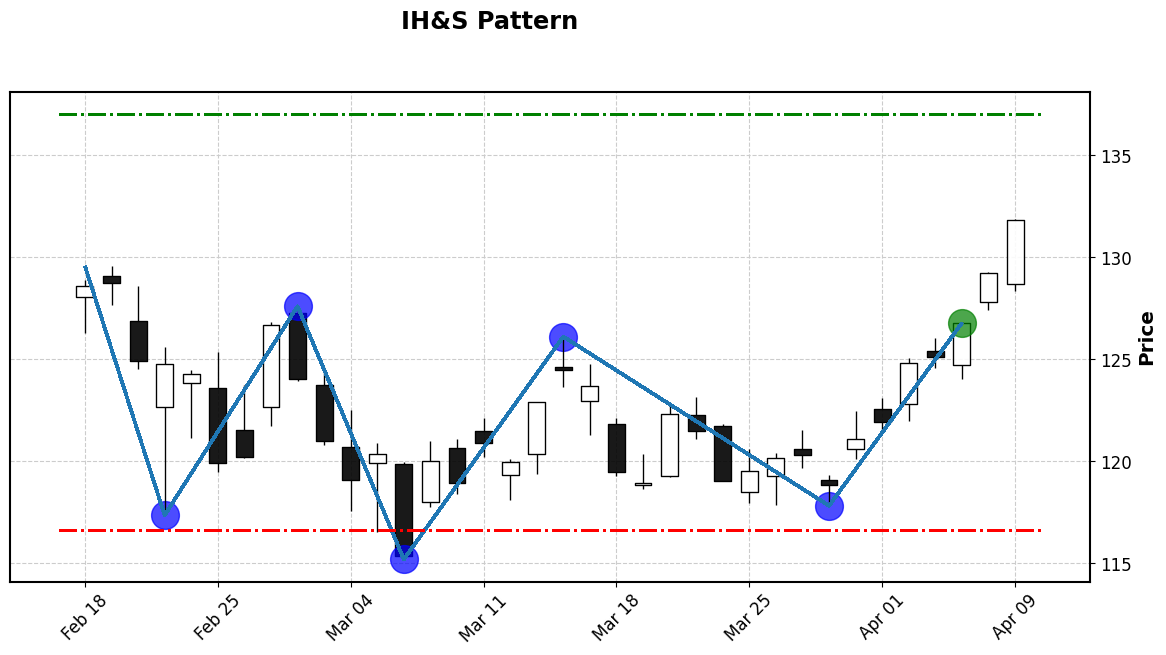

In [15]:
# Select the pattern to plot
ihs_patterns_to_plot = ihs_patterns_data.iloc[pattern_index]

# Candlestick plot of pattern along with stop-loss and profit target
mpf.plot(data_to_plot, type='candle', style='classic', addplot=ihs_plot,
         title='IH&S Pattern', figsize=(15, 7), alines=pattern_line,
         hlines=dict(hlines=[ihs_patterns_to_plot.target, ihs_patterns_to_plot.stoploss],
                     colors=['g', 'r'], linestyle='-.'))

As you can see in the above plot, you have successfully identified an inverse head and shoulders pattern based on the OHLCV data and defined its stop-loss and profit target to trade. 

<a id='conclusion'></a>
## Conclusion and Next Steps
In the upcoming Jupyter notebook, you will learn how to backtest the inverse head and shoulders pattern using the risk metrics calculated in this notebook.
<br><br>